<a href="https://colab.research.google.com/github/Sujan279/ML/blob/main/1BM23CS347_Lab_4_Logistic_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
upload = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv
Saving zoo-class-type.csv to zoo-class-type.csv
Saving zoo-data.csv to zoo-data.csv


   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

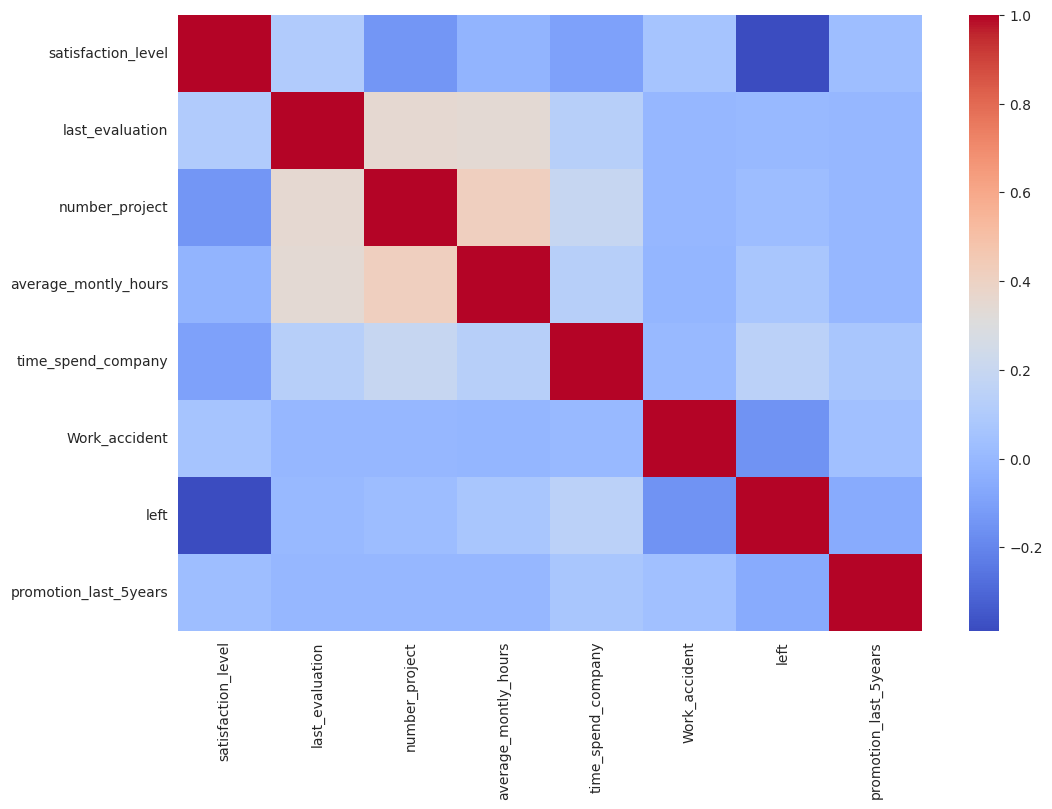

left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("HR_comma_sep.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df['left'].value_counts())

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

print(df.corr(numeric_only=True)['left'].sort_values(ascending=False))


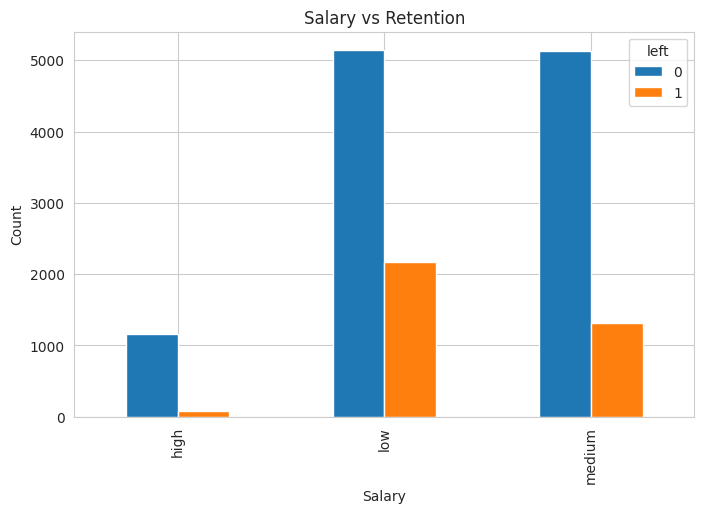

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("HR_comma_sep.csv")

salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar')
plt.title("Salary vs Retention")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

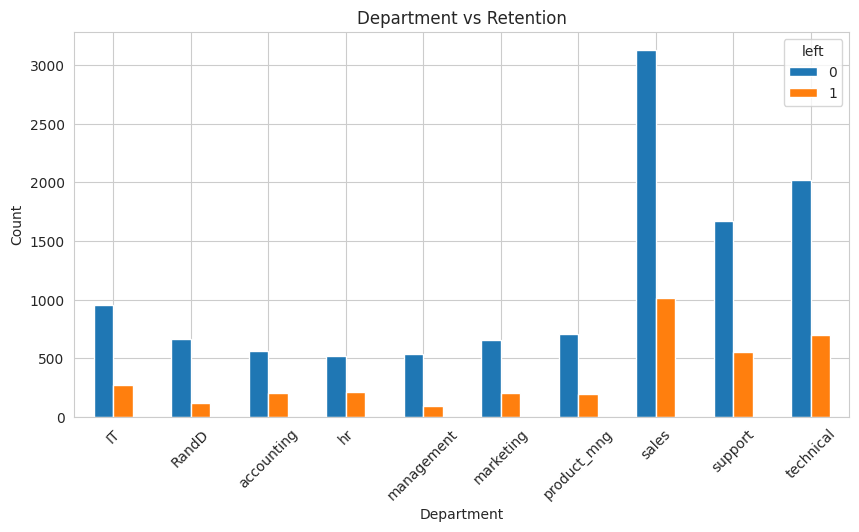

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("HR_comma_sep.csv")

dept_retention = pd.crosstab(df['Department'], df['left'])
dept_retention.plot(kind='bar', figsize=(10,5))
plt.title("Department vs Retention")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("HR_comma_sep.csv")

df['salary'] = df['salary'].map({'low':0,'medium':1,'high':2})

features = ['satisfaction_level','average_montly_hours','number_project',
            'time_spend_company','promotion_last_5years','salary']

X = df[features]
y = df['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7664444444444445
[[3167  261]
 [ 790  282]]
              precision    recall  f1-score   support

           0       0.80      0.92      0.86      3428
           1       0.52      0.26      0.35      1072

    accuracy                           0.77      4500
   macro avg       0.66      0.59      0.60      4500
weighted avg       0.73      0.77      0.74      4500



In [20]:
from google.colab import files
upload = files.upload()

Saving zoo-class-type.csv to zoo-class-type (1).csv
Saving zoo-data.csv to zoo-data (1).csv


In [22]:
import pandas as pd
import numpy as np

zoo = pd.read_csv("zoo-data.csv")
class_type = pd.read_csv("zoo-class-type (1).csv") # Changed filename here

zoo = zoo.drop(columns=['animal_name'])

print(zoo.head())
print(zoo.isnull().sum())

   hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  backbone  \
0     1         0     0     1         0        0         1        1         1   
1     1         0     0     1         0        0         0        1         1   
2     0         0     1     0         0        1         1        1         1   
3     1         0     0     1         0        0         1        1         1   
4     1         0     0     1         0        0         1        1         1   

   breathes  venomous  fins  legs  tail  domestic  catsize  class_type  
0         1         0     0     4     0         0        1           1  
1         1         0     0     4     1         0        1           1  
2         0         0     1     0     1         0        0           4  
3         1         0     0     4     0         0        1           1  
4         1         0     0     4     1         0        1           1  
hair          0
feathers      0
eggs          0
milk          0
airborne   

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = zoo.drop(columns=['class_type'])
y = zoo['class_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.9354838709677419
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.83      1.00      0.91         5
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.79      0.81      0.79        31
weighted avg       0.92      0.94      0.92        31



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


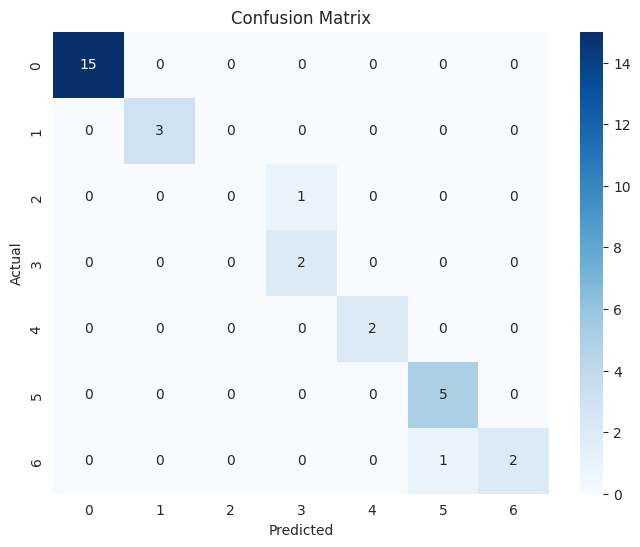

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()